In [4]:
import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('../../Features_Global/Features_Global_pol/pol_glob.csv')

df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Contrast,original_ngtdm_Strength,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,-117.0,26.0,2.513026e+07,3.210795,77.0,2.886965,160.0,44.972086,-45.445475,-47.0,...,0.055261,0.137056,TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,STD,2
1,-121.0,25.0,2.549979e+07,3.214234,79.0,2.714659,158.0,45.297845,-46.150897,-45.0,...,0.063519,0.118994,TO_LUNG_2_STD_1,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,STD,1
2,-127.0,37.0,3.029446e+07,3.422792,86.0,3.071614,172.0,51.220192,-45.546485,-46.0,...,0.062795,0.194055,TO_LUNG_2_FBP_3,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,3
3,-129.0,37.0,3.101561e+07,3.441222,86.0,3.134806,199.0,52.032888,-45.848897,-47.0,...,0.064719,0.192499,TO_LUNG_2_FBP_2,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,2
4,-134.0,37.0,3.156362e+07,3.456208,88.0,2.937853,176.0,52.668210,-46.365492,-45.0,...,0.066413,0.186759,TO_LUNG_2_FBP_1,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,33716.0,33789.0,5.526424e+12,2.283830,37.0,3.098956,33852.0,22.657438,33752.527108,33752.0,...,0.023946,0.051380,GE_LUNG_14_ASIR70_2,GE MEDICAL SYSTEMS,1.25,"[0.410156, 0.410156]",LUNG,14,ASIR70,2
92,33718.0,33789.0,5.526711e+12,2.246942,36.0,2.970794,33850.0,22.128363,33753.404659,33753.0,...,0.029074,0.037975,GE_LUNG_14_ASIR70_1,GE MEDICAL SYSTEMS,1.25,"[0.410156, 0.410156]",LUNG,14,ASIR70,1
93,33654.6,33857.0,3.972574e+12,3.732554,102.5,3.214628,34056.0,63.892932,33752.720390,33752.0,...,0.079821,0.402541,GE_LUNG_4_ASIR40_1,GE MEDICAL SYSTEMS,1.25,"[0.488281, 0.488281]",LUNG,4,ASIR40,1
94,33650.0,33860.0,3.973214e+12,3.760934,108.0,3.088317,34081.0,65.368402,33755.434184,33754.0,...,0.082686,0.402539,GE_LUNG_4_ASIR40_3,GE MEDICAL SYSTEMS,1.25,"[0.488281, 0.488281]",LUNG,4,ASIR40,3


In [6]:
scaler = MinMaxScaler()
df_reduced= df.iloc[:, :86]
df_last = df.iloc[:, 86:]
df_scaled = pd.DataFrame(scaler.fit_transform(df_reduced.iloc[:, :86]), columns=df_reduced.columns)
df_joined = df_scaled.join(df_last)
df = df_joined
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Contrast,original_ngtdm_Strength,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,0.000502,0.001268,0.000003,0.587684,0.396694,0.322733,0.003925,0.402676,0.000027,0.000000,...,0.055261,0.137056,TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,STD,2
1,0.000384,0.001239,0.000003,0.589171,0.413223,0.039354,0.003866,0.407313,0.000006,0.000059,...,0.063519,0.118994,TO_LUNG_2_STD_1,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,STD,1
2,0.000207,0.001593,0.000003,0.679313,0.471074,0.626412,0.004276,0.491612,0.000024,0.000030,...,0.062795,0.194055,TO_LUNG_2_FBP_3,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,3
3,0.000148,0.001593,0.000004,0.687279,0.471074,0.730338,0.005067,0.503180,0.000015,0.000000,...,0.064719,0.192499,TO_LUNG_2_FBP_2,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,2
4,0.000000,0.001593,0.000004,0.693756,0.487603,0.406425,0.004393,0.512224,0.000000,0.000059,...,0.066413,0.186759,TO_LUNG_2_FBP_1,TOSHIBA,1.00,"[0.427, 0.427]",LUNG,2,FBP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.999882,0.997021,0.999752,0.187035,0.066116,0.671379,0.990687,0.085045,0.999879,0.999882,...,0.023946,0.051380,GE_LUNG_14_ASIR70_2,GE MEDICAL SYSTEMS,1.25,"[0.410156, 0.410156]",LUNG,14,ASIR70,2
92,0.999941,0.997021,0.999804,0.171092,0.057851,0.460600,0.990628,0.077514,0.999905,0.999911,...,0.029074,0.037975,GE_LUNG_14_ASIR70_1,GE MEDICAL SYSTEMS,1.25,"[0.410156, 0.410156]",LUNG,14,ASIR70,1
93,0.998068,0.999027,0.718654,0.813197,0.607438,0.861615,0.996661,0.671998,0.999884,0.999882,...,0.079821,0.402541,GE_LUNG_4_ASIR40_1,GE MEDICAL SYSTEMS,1.25,"[0.488281, 0.488281]",LUNG,4,ASIR40,1
94,0.997932,0.999115,0.718769,0.825464,0.652893,0.653882,0.997393,0.693000,0.999965,0.999941,...,0.082686,0.402539,GE_LUNG_4_ASIR40_3,GE MEDICAL SYSTEMS,1.25,"[0.488281, 0.488281]",LUNG,4,ASIR40,3


In [7]:
#AGGIUNGO LA COLONNA PROTOCOLLO
# Define conditions and corresponding values for the new column
conditions = [
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'GE MEDICAL SYSTEMS'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 2) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 4) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 7) & (df['ASIR'] == 'FBP'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 7) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 14) & (df['ASIR'] == 'FBP'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 14) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'TOSHIBA'), (df['Dose'] == 2) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 2) & (df['ASIR'] == 'STD'), (df['Dose'] == 2) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 4) & (df['ASIR'] == 'STD'), (df['Dose'] == 4) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 8) & (df['ASIR'] == 'FBP'), (df['Dose'] == 8) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 8) & (df['ASIR'] == 'STD'), (df['Dose'] == 8) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 16) & (df['ASIR'] == 'FBP'), (df['Dose'] == 16) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 16) & (df['ASIR'] == 'STD'), (df['Dose'] == 16) & (df['ASIR'] == 'STRONG'),
    ]

new_column_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
                     27, 28, 29, 30, 31, 32]

# Add a new column based on the conditions
df['PROTOCOL'] = np.select(conditions, new_column_values, default=None)
pd.set_option('display.max_columns', None)
# Print the updated DataFrame
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_JointAverage,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_Imc1,original_glcm_Imc2,original_glcm_Idm,original_glcm_Idmn,original_glcm_Id,original_glcm_Idn,original_glcm_InverseVariance,original_glcm_MaximumProbability,original_glcm_SumEntropy,original_glcm_SumSquares,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL
0,0.000502,0.001268,0.000003,0.587684,0.396694,0.322733,0.003925,0.402676,0.000027,0.000000,0.001972,0.387387,0.407984,0.000710,0.671898,0.000003,0.231400,0.237081,0.210314,0.358639,0.072224,0.537806,0.237768,0.240374,0.661873,0.408099,0.565910,0.237117,0.112245,0.595008,0.723452,0.484406,0.331448,0.528602,0.356785,0.350796,0.464950,0.112112,0.591132,0.238755,0.365008,0.251265,0.236816,0.210699,0.141680,0.221824,0.082486,0.154251,0.463927,0.692744,0.713690,0.762672,0.124441,0.766772,0.205667,0.177862,0.375450,0.125853,0.341837,0.220602,0.045437,0.201414,0.008305,0.117219,0.278001,0.610442,0.676938,0.202449,0.161599,0.698053,0.318708,0.045932,0.634044,0.470886,0.470886,0.184255,0.244084,0.235650,0.210362,0.143270,0.312165,0.039885,0.156889,0.393332,0.108430,0.439056,4.076967,0.001415,182.716060,0.055261,0.137056,TO_LUNG_2_STD_2,TOSHIBA,1.00,

In [8]:
df_test1 = df[df['Num_Acquisition'] == 1]
df_test1 = df_test1.sort_values(by='PROTOCOL')
df_test1 = df_test1.iloc[:, :86]
df_test2 = df[df['Num_Acquisition'] == 2]
df_test2 = df_test2.sort_values(by='PROTOCOL')
df_test2 = df_test2.iloc[:, :86]
df_test3 = df[df['Num_Acquisition'] == 3]
df_test3 = df_test3.sort_values(by='PROTOCOL')
df_test3 = df_test3.iloc[:, :86]

df_test1

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_JointAverage,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_Imc1,original_glcm_Imc2,original_glcm_Idm,original_glcm_Idmn,original_glcm_Id,original_glcm_Idn,original_glcm_InverseVariance,original_glcm_MaximumProbability,original_glcm_SumEntropy,original_glcm_SumSquares,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis
50,0.997017,0.999912,9.998048e-01,0.982713,0.950413,0.518141,0.999736,0.959347,0.999901,0.999911,0.991257,0.981982,0.944630,0.999902,0.097634,9.998048e-01,0.008807,0.947270,0.896272,0.935322,0.903527,0.000000,0.937947,0.962928,0.607650,0.978494,0.987634,0.959701,0.002752,0.983255,0.374068,0.956237,0.008618,0.618131,0.009795,0.408972,0.009672,0.006146,0.980104,0.947404,0.049484,0.008899,0.948748,0.895434,0.005347,0.902349,0.003461,0.008516,0.975885,0.991453,0.992879,0.992152,0.006043,0.993911,0.893871,0.010636,0.993003,0.002137,0.988196,0.877032,0.000079,0.001235,0.000007,0.006341,0.980944,0.909660,0.924781,0.869262,0.010346,0.975354,0.982328,0.000077,0.969692,0.961962,0.961962,0.011891,0.025164,0.945213,0.897150,0.004705,0.852609,0.000564,0.008458,0.982263,0.865486,0.081745
54,0.997223,0.999705,9.997976e-01,0.947143,0.892562,0.529031,0.999121,0.894510,0.999898,0.999911,0.991757,0.924925,0.879924,0.999899,0.088253,9.997976e-01,0.023546,0.843656,0.787091,0.863136,0.719333,0.067462,0.835230,0.853457,0.621814,0.910319,0.947780,0.850163,0.008098,0.948315,0.42

In [9]:
#Protocols with different Dprime
ICC_list=[]
for jj in range(0, np.shape(df_test1)[1]):
    # rearrange dataframe for pingouin
    x1 = df_test1.iloc[:, jj].to_numpy(dtype=float)
    x2 = df_test2.iloc[:, jj].to_numpy(dtype=float)
    x3 = df_test3.iloc[:, jj].to_numpy(dtype=float)

    df1 = pd.DataFrame({'Values': x1})
    df1.insert(0, 'Protocol', range(1, len(df1)+1))
    df1['Test'] = 1

    df2 = pd.DataFrame({'Values': x2})
    df2.insert(0, 'Protocol', range(1, len(df2)+1))
    df2['Test'] = 2

    df3 = pd.DataFrame({'Values': x3})
    df3.insert(0, 'Protocol', range(1, len(df3)+1))
    df3['Test'] = 3


    df_final = pd.concat([df1, df2, df3])
    df_final = df_final[['Test', 'Protocol', 'Values']]
    df_final = df_final[(df_final['Protocol'] == 1) | (df_final['Protocol'] == 3) | (df_final['Protocol'] == 5) | 
                        (df_final['Protocol'] == 7) |(df_final['Protocol'] == 10) | (df_final['Protocol'] == 13) | 
                        (df_final['Protocol'] == 17) | (df_final['Protocol'] == 20) | (df_final['Protocol'] == 23) | 
                        (df_final['Protocol'] == 25) | (df_final['Protocol'] == 27) | (df_final['Protocol'] == 29) |
                        (df_final['Protocol'] == 30) | (df_final['Protocol'] == 32) ]  

    icc = pg.intraclass_corr(data=df_final, targets='Test', raters='Protocol', ratings='Values').round(3)
    ICC_list.append(icc.iloc[5,2])

df_final

/Users/mariairenetenerani/anaconda3/envs/Apple_tensorflow_env/lib/python3.10/site-packages/pingouin/reliability.py:367: RuntimeWarning: invalid value encountered in scalar divide
  l2 = n * (msb - f2u * mse) / (f2u * (k * msj + (k * n - k - n) * mse) + n * msb)


,Test,Protocol,Values
0,1,1,0.081745
2,1,3,0.128655
4,1,5,0.184652
6,1,7,0.146686
9,1,10,0.386237
12,1,13,0.755720
16,1,17,0.258422
19,1,20,0.733789
22,1,23,0.706057
24,1,25,0.470024


In [10]:
print(icc)
print(ICC_list)

features_names = df_test1.columns

    Type              Description    ICC      F  df1  df2   pval  \
0   ICC1   Single raters absolute -0.067  0.119    2   39  0.888   
1   ICC2     Single random raters -0.024  0.269    2   26  0.767   
2   ICC3      Single fixed raters -0.055  0.269    2   26  0.767   
3  ICC1k  Average raters absolute -7.383  0.119    2   39  0.888   
4  ICC2k    Average random raters -0.481  0.269    2   26  0.767   
5  ICC3k     Average fixed raters -2.723  0.269    2   26  0.767   

            CI95%  
0   [-0.07, 0.21]  
1   [-0.03, 0.23]  
2   [-0.07, 0.41]  
3  [-33.04, 0.79]  
4   [-0.79, 0.81]  
5  [-14.88, 0.91]  
[0.666, -3.247, 0.761, 0.094, -0.237, 0.731, -6.385, 0.085, 0.913, 0.788, -1.871, -89.924, 0.209, -4.39, 0.046, 0.761, 0.064, -0.351, -2.782, -3.275, -4.105, -0.431, -1.151, -0.06, 0.689, 0.316, 0.283, -0.251, -1.153, 0.104, 0.779, 0.838, 0.399, 0.792, 0.396, 0.804, 0.408, 0.35, -0.234, -0.525, -0.025, -0.319, -0.311, -2.522, -0.609, -6.488, -0.856, -0.411, -0.741, 0.365, 0.22, 0.

In [11]:
ICC_array = np.asarray(ICC_list)
ind = ICC_array.argsort()
ind = ind[::-1] #prendo gli indici delle ICC dallo score maggiore allo score minore
score=[]
name=[]
for i in ind:
    score.append(ICC_list[i])
    name.append(df_test1.columns[i])

result = pd.DataFrame(score, columns = ['ICC'])
result['name'] = name

nn = result['name'].str.split('_', n = 2, expand = True)
result['type'] = nn[1]
#result['image'] = nn[3]
result['R'] = 'ok'

result.loc[(result["ICC"] >= -1.0) & (result["ICC"]<0.5), "R"] = 'Poor'
result.loc[result["ICC"] >= 0.9, "R"] = 'Excellent'

result.loc[result["ICC"] < -1.0, "R"] = 'Inconsistent'

result.loc[(result["ICC"] > 0.5) & (result["ICC"]<0.75) , "R"] = 'Moderate'
result.loc[(result["ICC"] >= 0.75) & (result["ICC"]<0.9), "R"] = 'Good'


#result_ALL = result
#result_ALL
result_ALL = result
result_ALL

,ICC,name,type,R
0,0.913,original_firstorder_Mean,firstorder,Excellent
1,0.838,original_glcm_Imc2,glcm,Good
2,0.804,original_glcm_Idn,glcm,Good
3,0.792,original_glcm_Idmn,glcm,Good
4,0.788,original_firstorder_Median,firstorder,Good
...,...,...,...,...
81,-5.603,original_glszm_LargeAreaEmphasis,glszm,Inconsistent
82,-5.830,original_glszm_ZoneVariance,glszm,Inconsistent
83,-6.385,original_firstorder_Maximum,firstorder,Inconsistent
84,-6.488,original_glrlm_LongRunHighGrayLevelEmphasis,glrlm,Inconsistent


In [12]:
#Protocols with similar Dprime

ICC_list=[]

for jj in range(0, np.shape(df_test1)[1]):
    # rearrange dataframe for pingouin
    x1 = df_test1.iloc[:, jj].to_numpy(dtype=float)
    x2 = df_test2.iloc[:, jj].to_numpy(dtype=float)
    x3 = df_test3.iloc[:, jj].to_numpy(dtype=float)

    df1 = pd.DataFrame({'Values': x1})
    df1.insert(0, 'Protocol', range(1, len(df1)+1))
    df1['Test'] = 1

    df2 = pd.DataFrame({'Values': x2})
    df2.insert(0, 'Protocol', range(1, len(df2)+1))
    df2['Test'] = 2

    df3 = pd.DataFrame({'Values': x3})
    df3.insert(0, 'Protocol', range(1, len(df3)+1))
    df3['Test'] = 3


    df_final = pd.concat([df1, df2, df3])
    df_final = df_final[['Test', 'Protocol', 'Values']]
    df_final = df_final[(df_final['Protocol'] == 8) | (df_final['Protocol'] == 9) | (df_final['Protocol'] == 10) | 
                        (df_final['Protocol'] == 11) |(df_final['Protocol'] == 12) | (df_final['Protocol'] == 13) | 
                        (df_final['Protocol'] == 14) | (df_final['Protocol'] == 18) | (df_final['Protocol'] == 19) | 
                        (df_final['Protocol'] == 20) | (df_final['Protocol'] == 21) | (df_final['Protocol'] == 22) | 
                        (df_final['Protocol'] == 23) | (df_final['Protocol'] == 24) ]   
    
    icc = pg.intraclass_corr(data=df_final, targets='Test', raters='Protocol', ratings='Values').round(3)
    ICC_list.append(icc.iloc[5,2])

df_final

,Test,Protocol,Values
7,1,8,0.357013
8,1,9,0.575906
9,1,10,0.386237
10,1,11,0.349839
11,1,12,0.271573
12,1,13,0.755720
13,1,14,0.619523
17,1,18,0.463534
18,1,19,0.733789
19,1,20,0.733789


In [13]:
print(icc)
print(ICC_list)

    Type              Description    ICC       F  df1  df2   pval  \
0   ICC1   Single raters absolute  0.305   7.131    2   39  0.002   
1   ICC2     Single random raters  0.318  11.950    2   26  0.000   
2   ICC3      Single fixed raters  0.439  11.950    2   26  0.000   
3  ICC1k  Average raters absolute  0.860   7.131    2   39  0.002   
4  ICC2k    Average random raters  0.867  11.950    2   26  0.000   
5  ICC3k     Average fixed raters  0.916  11.950    2   26  0.000   

          CI95%  
0  [0.05, 0.95]  
1  [0.07, 0.95]  
2  [0.11, 0.97]  
3   [0.43, 1.0]  
4   [0.53, 1.0]  
5   [0.64, 1.0]  
[0.891, 0.742, 0.748, 0.809, 0.815, 0.163, 0.694, 0.834, 0.923, 0.801, -0.094, -0.024, 0.831, 0.211, 0.307, 0.748, 0.773, 0.84, -0.449, -0.247, 0.798, -48.909, 0.813, 0.849, 0.886, 0.855, 0.837, 0.837, 0.686, 0.805, 0.932, 0.868, 0.851, 0.889, 0.852, 0.9, 0.856, 0.818, 0.742, 0.831, 0.788, 0.785, 0.838, -1.261, 0.82, 0.671, 0.466, 0.644, 0.759, 0.86, 0.863, 0.845, 0.8, 0.858, -4.896, 0.6

In [14]:
ICC_array = np.asarray(ICC_list)
ind = ICC_array.argsort()
ind = ind[::-1] #prendo gli indici delle ICC dallo score maggiore allo score minore
score=[]
name=[]
for i in ind:
    score.append(ICC_list[i])
    name.append(df_test1.columns[i])

result = pd.DataFrame(score, columns = ['ICC'])
result['name'] = name

nn = result['name'].str.split('_', n = 2, expand = True)
result['type'] = nn[1]
#result['image'] = nn[3]
result['R'] = 'ok'

result.loc[(result["ICC"] >= -1.0) & (result["ICC"]<0.5), "R"] = 'Poor'
result.loc[result["ICC"] >= 0.9, "R"] = 'Excellent'

result.loc[result["ICC"] < -1.0, "R"] = 'Inconsistent'

result.loc[(result["ICC"] >= 0.5) & (result["ICC"]<0.75) , "R"] = 'Moderate'
result.loc[(result["ICC"] >= 0.75) & (result["ICC"]<0.9), "R"] = 'Good'

result_DPRIME = result
result_DPRIME

,ICC,name,type,R
0,0.943,original_glszm_LargeAreaHighGrayLevelEmphasis,glszm,Excellent
1,0.932,original_glcm_Imc1,glcm,Excellent
2,0.923,original_firstorder_Mean,firstorder,Excellent
3,0.917,original_gldm_LargeDependenceHighGrayLevelEmph...,gldm,Excellent
4,0.916,original_gldm_SmallDependenceLowGrayLevelEmphasis,gldm,Excellent
...,...,...,...,...
81,-4.896,original_glrlm_ShortRunHighGrayLevelEmphasis,glrlm,Inconsistent
82,-4.898,original_gldm_DependenceEntropy,gldm,Inconsistent
83,-4.937,original_glszm_ZoneEntropy,glszm,Inconsistent
84,-5.745,original_glszm_SmallAreaHighGrayLevelEmphasis,glszm,Inconsistent


In [15]:
pd.set_option('display.max_rows', None)
result_total = result_ALL.merge(result_DPRIME, on='name')
result_total

,ICC_x,name,type_x,R_x,ICC_y,type_y,R_y
0,0.913,original_firstorder_Mean,firstorder,Excellent,0.923,firstorder,Excellent
1,0.838,original_glcm_Imc2,glcm,Good,0.868,glcm,Good
2,0.804,original_glcm_Idn,glcm,Good,0.900,glcm,Excellent
3,0.792,original_glcm_Idmn,glcm,Good,0.889,glcm,Good
4,0.788,original_firstorder_Median,firstorder,Good,0.801,firstorder,Good
5,0.779,original_glcm_Imc1,glcm,Good,0.932,glcm,Excellent
6,0.761,original_firstorder_TotalEnergy,firstorder,Good,0.748,firstorder,Moderate
7,0.761,original_firstorder_Energy,firstorder,Good,0.748,firstorder,Moderate
8,0.731,original_firstorder_Kurtosis,firstorder,Moderate,0.163,firstorder,Poor
9,0.692,original_gldm_DependenceVariance,gldm,Moderate,0.822,gldm,Good


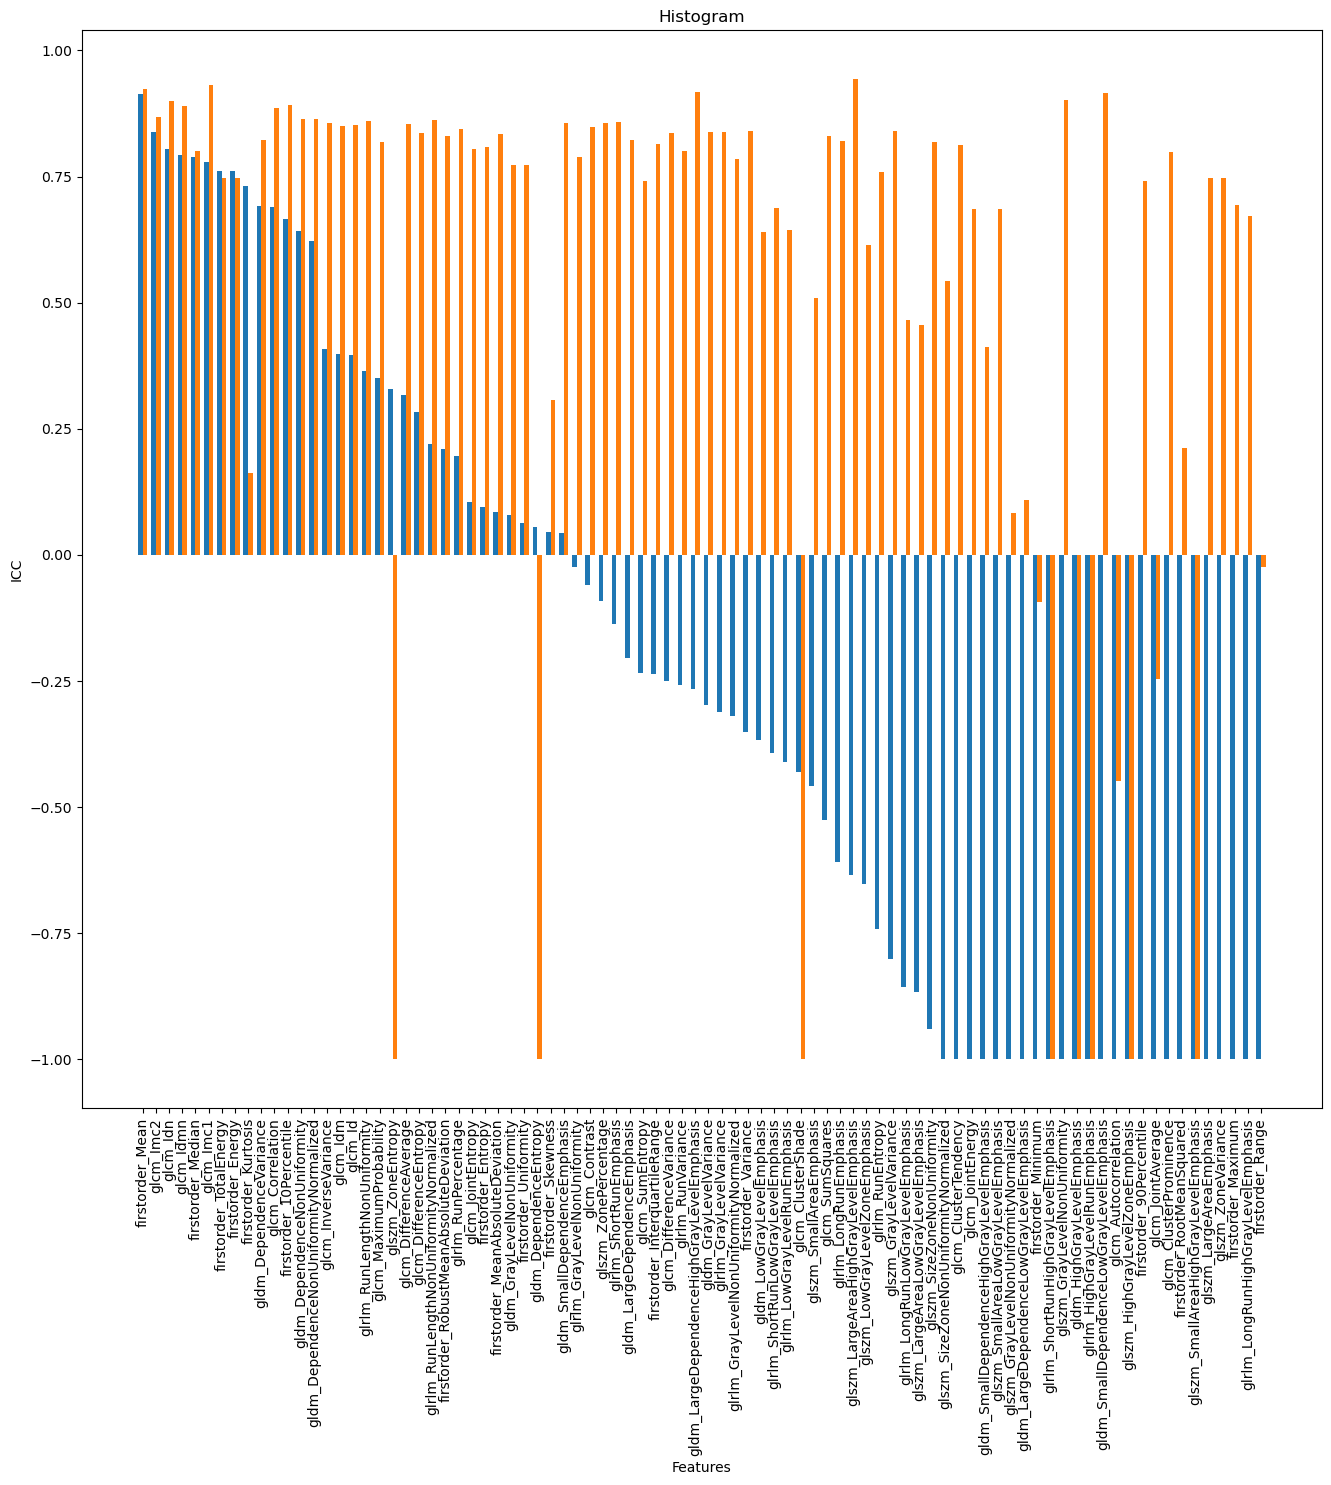

In [16]:
substring = 'original_'
new_column_names = []
for i in range(len(result_total['name'])):
    new_string = result_total['name'][i].replace(substring, "")
    new_column_names.append(new_string)

#Plot the histogram
plt.figure(figsize=(16,14))

transformed_numbers_all = [-1 if num < -1 else num for num in result_total['ICC_x']]
transformed_numbers_dprime = [-1 if num < -1 else num for num in result_total['ICC_y']]

bar_width = 0.35

# Set the positions of the bars on the x-axis
bar_positions1 = np.arange(len(transformed_numbers_all))
bar_positions2 = bar_positions1 + bar_width

plt.bar(bar_positions1, transformed_numbers_all, bar_width, align='center', label='all')
plt.bar(bar_positions2, transformed_numbers_dprime, bar_width, align='center', label = 'similar dprime')

# Set custom labels for the x-axis ticks
plt.xticks(bar_positions1 + bar_width/2, new_column_names, rotation=90)
#plt.xticks(rotation=90)

# Add labels and title

plt.xlabel('Features')
plt.ylabel('ICC')
plt.title('Histogram')

# Show the plot
plt.show()

In [17]:
Excellent_value_count_ALL = len(result_ALL[result_ALL['R'] == 'Excellent'])
print(f'Excellent:', Excellent_value_count_ALL)
Good_value_count_ALL = len(result_ALL[result_ALL['R'] == 'Good'])
print(f'Good:', Good_value_count_ALL)
Moderate_value_count_ALL = len(result_ALL[result_ALL['R'] == 'Moderate'])
print(f'Moderate:', Moderate_value_count_ALL)
Poor_value_count_ALL = len(result_ALL[result_ALL['R'] == 'Poor'])
print(f'Poor:', Poor_value_count_ALL)
Inconsistent_value_count_All = len(result_ALL[result_ALL['R'] == 'Inconsistent'])
print(f'Inconsistent:', Inconsistent_value_count_All)

Excellent: 1
Good: 7
Moderate: 6
Poor: 47
Inconsistent: 25


In [18]:
Excellent_value_count_dprime = len(result_DPRIME[result_DPRIME['R'] == 'Excellent'])
print(f'Excellent:', Excellent_value_count_dprime)
Good_value_count_dprime = len(result_DPRIME[result_DPRIME['R'] == 'Good'])
print(f'Good:', Good_value_count_dprime)
Moderate_value_count_dprime = len(result_DPRIME[result_DPRIME['R'] == 'Moderate'])
print(f'Moderate:', Moderate_value_count_dprime)
Poor_value_count_dprime = len(result_DPRIME[result_DPRIME['R'] == 'Poor'])
print(f'Poor:', Poor_value_count_dprime)
Inconsistent_value_count_dprime = len(result_DPRIME[result_DPRIME['R'] == 'Inconsistent'])
print(f'Inconsistent:', Inconsistent_value_count_dprime)

Excellent: 7
Good: 43
Moderate: 16
Poor: 12
Inconsistent: 8


<Figure size 640x480 with 0 Axes>

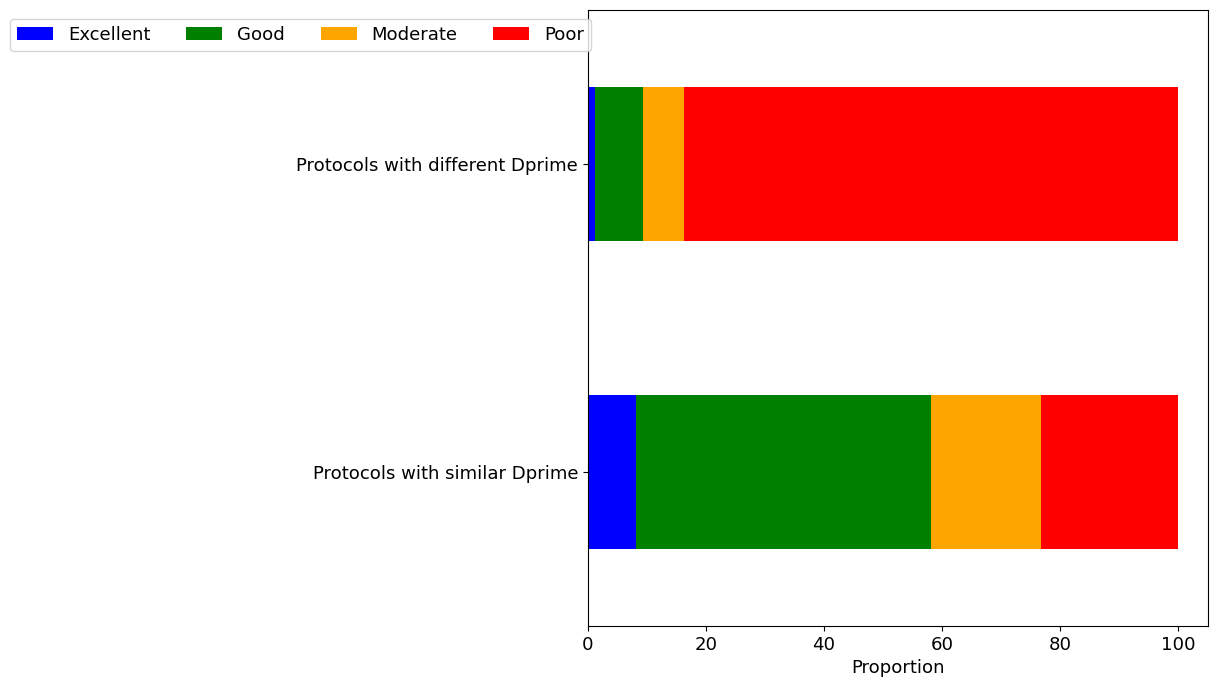

In [19]:
array = np.array([[Excellent_value_count_dprime*100/86, Good_value_count_dprime*100/86, Moderate_value_count_dprime*100/86, (Poor_value_count_dprime+Inconsistent_value_count_dprime)*100/86],  
                  [Excellent_value_count_ALL*100/86, Good_value_count_ALL*100/86, Moderate_value_count_ALL*100/86, (Poor_value_count_ALL+ Inconsistent_value_count_All)*100/86]
                  ])

index_values = ['Protocols with similar Dprime', 'Protocols with different Dprime']
column_values = ['Excellent', 'Good', 'Moderate', 'Poor']
df_fig = pd.DataFrame(data = array,
                  index = index_values,
                  columns = column_values)

plt.figure()
df_fig.plot(kind="barh", figsize =(8, 8), fontsize=13, rot=0, stacked=True, color=['blue', 'green', 'orange', 'red'])
#plt.ylabel('Reconstruction Algorithm',fontsize=13)
plt.xlabel('Proportion',fontsize=13)
plt.legend(bbox_to_anchor =(0.02, 1),fontsize=13, ncol=4)
plt.savefig('Boxplot.png')

In [20]:
# Define the condition
condition = result_total['ICC_y'] > result_total['ICC_x']  # Example condition: Age greater than 25
condition2 = result_total['ICC_y'] < result_total['ICC_x'] 
condition3 = result_total['R_y'] != result_total['R_x'] 

# Filter the DataFrame based on the condition
filtered_df = result_total[condition]
filtered_df2 = result_total[condition2]
condition3 = filtered_df['R_y'] != filtered_df['R_x'] 
filtered_category = filtered_df[condition3]

# Print the number of rows that satisfy the condition
num_rows = len(filtered_df)
num_rows2 = len(filtered_df2)
num_rows3 = len(filtered_category)

print("Number of features that improves ICC with similar Dprime: ", num_rows)
print("Number of features that improves the category: ", num_rows3)
print("Number of features that worsens ICC with similar Dprime: ", num_rows2)

Number of features that improves ICC with similar Dprime:  77
Number of features that improves the category:  68
Number of features that worsens ICC with similar Dprime:  9


In [21]:
result_total.groupby(['type_x', 'R_x']).size()

type_x      R_x         
firstorder  Excellent        1
            Good             3
            Inconsistent     5
            Moderate         2
            Poor             7
glcm        Good             4
            Inconsistent     5
            Moderate         1
            Poor            12
gldm        Inconsistent     4
            Moderate         3
            Poor             7
glrlm       Inconsistent     3
            Poor            13
glszm       Inconsistent     8
            Poor             8
dtype: int64

In [22]:
result_total.groupby(['type_y', 'R_y']).size()

type_y      R_y         
firstorder  Excellent        1
            Good             8
            Moderate         4
            Poor             5
glcm        Excellent        2
            Good            15
            Inconsistent     1
            Moderate         2
            Poor             2
gldm        Excellent        2
            Good             7
            Inconsistent     2
            Moderate         1
            Poor             2
glrlm       Good            10
            Inconsistent     2
            Moderate         3
            Poor             1
glszm       Excellent        2
            Good             3
            Inconsistent     3
            Moderate         6
            Poor             2
dtype: int64

<Figure size 640x480 with 0 Axes>

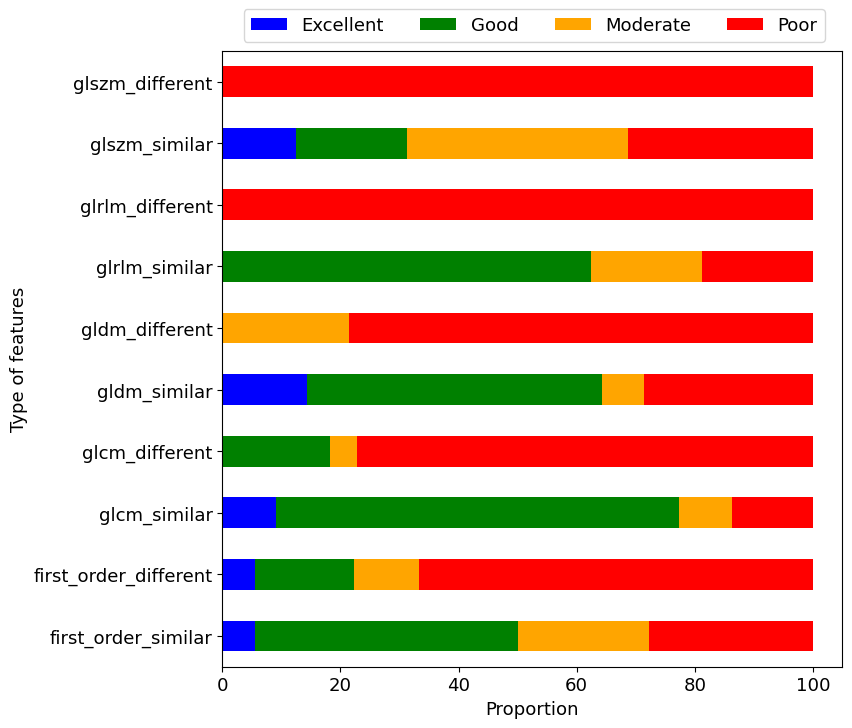

In [23]:
firstorder_number = result_total.groupby(['type_y']).size().get(('firstorder'),0)

firstorder_similar_Excellent= result_total.groupby(['type_y', 'R_y']).size().get(('firstorder', 'Excellent'),0)
firstorder_similar_Good = result_total.groupby(['type_y', 'R_y']).size().get(('firstorder', 'Good'),0)
firstorder_similar_Moderate = result_total.groupby(['type_y', 'R_y']).size().get(('firstorder', 'Moderate'),0)
firstorder_similar_Poor = result_total.groupby(['type_y', 'R_y']).size().get(('firstorder', 'Poor'),0)
firstorder_similar_Inconsistent = result_total.groupby(['type_y', 'R_y']).size().get(('firstorder', 'Inconsistent'),0)

firstorder_different_Excellent= result_total.groupby(['type_x', 'R_x']).size().get(('firstorder', 'Excellent'),0)
firstorder_different_Good = result_total.groupby(['type_x', 'R_x']).size().get(('firstorder', 'Good'),0)
firstorder_different_Moderate = result_total.groupby(['type_x', 'R_x']).size().get(('firstorder', 'Moderate'),0)
firstorder_different_Poor = result_total.groupby(['type_x', 'R_x']).size().get(('firstorder', 'Poor'),0)
firstorder_different_Inconsistent = result_total.groupby(['type_x', 'R_x']).size().get(('firstorder', 'Inconsistent'),0)

glcm_number = result_total.groupby(['type_y']).size().get(('glcm'),0)
glcm_similar_Excellent= result_total.groupby(['type_y', 'R_y']).size().get(('glcm', 'Excellent'),0)
glcm_similar_Good = result_total.groupby(['type_y', 'R_y']).size().get(('glcm', 'Good'),0)
glcm_similar_Moderate = result_total.groupby(['type_y', 'R_y']).size().get(('glcm', 'Moderate'),0)
glcm_similar_Poor = result_total.groupby(['type_y', 'R_y']).size().get(('glcm', 'Poor'),0)
glcm_similar_Inconsistent = result_total.groupby(['type_y', 'R_y']).size().get(('glcm', 'Inconsistent'),0)

glcm_different_Excellent= result_total.groupby(['type_x', 'R_x']).size().get(('glcm', 'Excellent'),0)
glcm_different_Good = result_total.groupby(['type_x', 'R_x']).size().get(('glcm', 'Good'),0)
glcm_different_Moderate = result_total.groupby(['type_x', 'R_x']).size().get(('glcm', 'Moderate'),0)
glcm_different_Poor = result_total.groupby(['type_x', 'R_x']).size().get(('glcm', 'Poor'),0)
glcm_different_Inconsistent = result_total.groupby(['type_x', 'R_x']).size().get(('glcm', 'Inconsistent'),0)

gldm_number = result_total.groupby(['type_y']).size().get(('gldm'),0)
gldm_similar_Excellent= result_total.groupby(['type_y', 'R_y']).size().get(('gldm', 'Excellent'),0)
gldm_similar_Good = result_total.groupby(['type_y', 'R_y']).size().get(('gldm', 'Good'),0)
gldm_similar_Moderate = result_total.groupby(['type_y', 'R_y']).size().get(('gldm', 'Moderate'),0)
gldm_similar_Poor = result_total.groupby(['type_y', 'R_y']).size().get(('gldm', 'Poor'),0)
gldm_similar_Inconsistent = result_total.groupby(['type_y', 'R_y']).size().get(('gldm', 'Inconsistent'),0)
gldm_different_Excellent= result_total.groupby(['type_x', 'R_x']).size().get(('gldm', 'Excellent'),0)
gldm_different_Good = result_total.groupby(['type_x', 'R_x']).size().get(('gldm', 'Good'),0)
gldm_different_Moderate = result_total.groupby(['type_x', 'R_x']).size().get(('gldm', 'Moderate'),0)
gldm_different_Poor = result_total.groupby(['type_x', 'R_x']).size().get(('gldm', 'Poor'),0)
gldm_different_Inconsistent = result_total.groupby(['type_x', 'R_x']).size().get(('gldm', 'Inconsistent'),0)

glrlm_number = result_total.groupby(['type_y']).size().get(('glrlm'),0)
glrlm_similar_Excellent= result_total.groupby(['type_y', 'R_y']).size().get(('glrlm', 'Excellent'),0)
glrlm_similar_Good = result_total.groupby(['type_y', 'R_y']).size().get(('glrlm', 'Good'),0)
glrlm_similar_Moderate = result_total.groupby(['type_y', 'R_y']).size().get(('glrlm', 'Moderate'),0)
glrlm_similar_Poor = result_total.groupby(['type_y', 'R_y']).size().get(('glrlm', 'Poor'),0)
glrlm_similar_Inconsistent = result_total.groupby(['type_y', 'R_y']).size().get(('glrlm', 'Inconsistent'),0)
glrlm_different_Excellent= result_total.groupby(['type_x', 'R_x']).size().get(('glrlm', 'Excellent'),0)
glrlm_different_Good = result_total.groupby(['type_x', 'R_x']).size().get(('glrlm', 'Good'),0)
glrlm_different_Moderate = result_total.groupby(['type_x', 'R_x']).size().get(('glrlm', 'Moderate'),0)
glrlm_different_Poor = result_total.groupby(['type_x', 'R_x']).size().get(('glrlm', 'Poor'),0)
glrlm_different_Inconsistent = result_total.groupby(['type_x', 'R_x']).size().get(('glrlm', 'Inconsistent'),0)

glszm_number = result_total.groupby(['type_y']).size().get(('glszm'),0)
glszm_similar_Excellent= result_total.groupby(['type_y', 'R_y']).size().get(('glszm', 'Excellent'),0)
glszm_similar_Good = result_total.groupby(['type_y', 'R_y']).size().get(('glszm', 'Good'),0)
glszm_similar_Moderate = result_total.groupby(['type_y', 'R_y']).size().get(('glszm', 'Moderate'),0)
glszm_similar_Poor = result_total.groupby(['type_y', 'R_y']).size().get(('glszm', 'Poor'),0)
glszm_similar_Inconsistent = result_total.groupby(['type_y', 'R_y']).size().get(('glszm', 'Inconsistent'),0)
glszm_different_Excellent= result_total.groupby(['type_x', 'R_x']).size().get(('glszm', 'Excellent'),0)
glszm_different_Good = result_total.groupby(['type_x', 'R_x']).size().get(('glszm', 'Good'),0)
glszm_different_Moderate = result_total.groupby(['type_x', 'R_x']).size().get(('glszm', 'Moderate'),0)
glszm_different_Poor = result_total.groupby(['type_x', 'R_x']).size().get(('glszm', 'Poor'),0)
glszm_different_Inconsistent = result_total.groupby(['type_x', 'R_x']).size().get(('glszm', 'Inconsistent'),0)



array = np.array([ 
                  [firstorder_similar_Excellent*100/(firstorder_number), firstorder_similar_Good*100/(firstorder_number), firstorder_similar_Moderate*100/(firstorder_number), (firstorder_similar_Poor+firstorder_similar_Inconsistent)*100/(firstorder_number)],
                  [firstorder_different_Excellent*100/(firstorder_number), firstorder_different_Good*100/(firstorder_number), firstorder_different_Moderate*100/(firstorder_number), (firstorder_different_Poor+firstorder_different_Inconsistent)*100/(firstorder_number)],
                  [glcm_similar_Excellent*100/(glcm_number), glcm_similar_Good*100/(glcm_number), glcm_similar_Moderate*100/(glcm_number), (glcm_similar_Poor+glcm_similar_Inconsistent)*100/(glcm_number)],
                  [glcm_different_Excellent*100/(glcm_number), glcm_different_Good*100/(glcm_number), glcm_different_Moderate*100/(glcm_number), (glcm_different_Poor+glcm_different_Inconsistent)*100/(glcm_number)],
                [gldm_similar_Excellent*100/(gldm_number), gldm_similar_Good*100/(gldm_number), gldm_similar_Moderate*100/(gldm_number), (gldm_similar_Poor+gldm_similar_Inconsistent)*100/(gldm_number)],
                    [gldm_different_Excellent*100/(gldm_number), gldm_different_Good*100/(gldm_number), gldm_different_Moderate*100/(gldm_number), (gldm_different_Poor+gldm_different_Inconsistent)*100/(gldm_number)],
                    [glrlm_similar_Excellent*100/(glrlm_number), glrlm_similar_Good*100/(glrlm_number), glrlm_similar_Moderate*100/(glrlm_number), (glrlm_similar_Poor+glrlm_similar_Inconsistent)*100/(glrlm_number)],
                    [glrlm_different_Excellent*100/(glrlm_number), glrlm_different_Good*100/(glrlm_number), glrlm_different_Moderate*100/(glrlm_number), (glrlm_different_Poor+glrlm_different_Inconsistent)*100/(glrlm_number)],
                    [glszm_similar_Excellent*100/(glszm_number), glszm_similar_Good*100/(glszm_number), glszm_similar_Moderate*100/(glszm_number), (glszm_similar_Poor+glszm_similar_Inconsistent)*100/(glszm_number)],
                    [glszm_different_Excellent*100/(glszm_number), glszm_different_Good*100/(glszm_number), glszm_different_Moderate*100/(glszm_number), (glszm_different_Poor+glszm_different_Inconsistent)*100/(glszm_number)]
                    ])


index_values = ['first_order_similar', 'first_order_different','glcm_similar', 'glcm_different', 'gldm_similar', 'gldm_different', 'glrlm_similar', 'glrlm_different', 'glszm_similar', 'glszm_different']
column_values = ['Excellent', 'Good', 'Moderate', 'Poor']
df_fig = pd.DataFrame(data = array,
                  index = index_values,
                  columns = column_values)

plt.figure()
df_fig.plot(kind="barh", figsize =(8, 8), fontsize=13, rot=0, stacked=True, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Type of features',fontsize=13)
plt.xlabel('Proportion',fontsize=13)
plt.legend(bbox_to_anchor =(0.02, 1),fontsize=13, ncol=4)

In [24]:
# sort the dataframe by the column 'PROTOCOL_new'
df_sorted = df.sort_values(['PROTOCOL'])

df_sorted

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_JointAverage,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_Imc1,original_glcm_Imc2,original_glcm_Idm,original_glcm_Idmn,original_glcm_Id,original_glcm_Idn,original_glcm_InverseVariance,original_glcm_MaximumProbability,original_glcm_SumEntropy,original_glcm_SumSquares,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL
50,0.997017,0.999912,9.998048e-01,0.982713,0.950413,0.518141,0.999736,0.959347,0.999901,0.999911,0.991257,0.981982,0.944630,0.999902,0.097634,9.998048e-01,0.008807,0.947270,0.896272,0.935322,0.903527,0.000000,0.937947,0.962928,0.607650,0.978494,0.987634,0.959701,0.002752,0.983255,0.374068,0.956237,0.008618,0.618131,0.009795,0.408972,0.009672,0.006146,0.980104,0.947404,0.049484,0.008899,0.948748,0.895434,0.005347,0.902349,0.003461,0.008516,0.975885,0.991453,0.992879,0.992152,0.006043,0.993911,0.893871,0.010636,0.993003,0.002137,0.988196,0.877032,0.000079,0.001235,0.000007,0.006341,0.980944,0.909660,0.924781,0.869262,0.010346,0.975354,0.982328,0.000077,0.969692,0.961962,0.961962,0.011891,0.025164,0.945213,0.897150,0.004705,0.852609,0.000564,0.008458,0.982263,0.865486,0.081745,1.007483,0.001488,1275.918828,0.093510,0.537100,GE_LUNG_2_FBP_1,GE 

In [25]:
# Select only the ones with Protocol = 1
df_1 = df_sorted[df_sorted['PROTOCOL'] == 1]

#Select only the ones with PROTOCOL = 2
df_2 = df_sorted[df_sorted['PROTOCOL'] == 2]

#Select only the ones with PROTOCOL = 3
df_3 = df_sorted[df_sorted['PROTOCOL'] == 3]

#Select only the ones with PROTOCOL = 4
df_4 = df_sorted[df_sorted['PROTOCOL'] == 4]

#Select only the ones with PROTOCOL = 5
df_5 = df_sorted[df_sorted['PROTOCOL'] == 5]

#Select only the ones with PROTOCOL = 6
df_6 = df_sorted[df_sorted['PROTOCOL'] == 6]

#Select only the ones with PROTOCOL = 7
#df_7 = df_sorted[df_sorted['PROTOCOL'] == 7]

#Select only the ones with PROTOCOL = 8
df_8 = df_sorted[df_sorted['PROTOCOL'] == 8]

#Select only the ones with PROTOCOL = 9
df_9 = df_sorted[df_sorted['PROTOCOL'] == 9]

#Select only the ones with PROTOCOL = 10
df_10 = df_sorted[df_sorted['PROTOCOL'] == 10]

#Select only the ones with PROTOCOL = 11
df_11 = df_sorted[df_sorted['PROTOCOL'] == 11]

#Select only the ones with PROTOCOL = 12
df_12 = df_sorted[df_sorted['PROTOCOL'] == 12]

#Select only the ones with PROTOCOL = 13
df_13 = df_sorted[df_sorted['PROTOCOL'] == 13]

#Select only the ones with PROTOCOL = 14
df_14 = df_sorted[df_sorted['PROTOCOL'] == 14]

#Select only the ones with PROTOCOL = 15
df_15 = df_sorted[df_sorted['PROTOCOL'] == 15]

#Select only the ones with PROTOCOL = 16
df_16 = df_sorted[df_sorted['PROTOCOL'] == 16]

#Select only the ones with PROTOCOL = 17
df_17 = df_sorted[df_sorted['PROTOCOL'] == 17]

#Select only the ones with PROTOCOL = 18
df_18 = df_sorted[df_sorted['PROTOCOL'] == 18]

#Select only the ones with PROTOCOL = 19
df_19 = df_sorted[df_sorted['PROTOCOL'] == 19]

#Select only the ones with PROTOCOL = 20
df_20 = df_sorted[df_sorted['PROTOCOL'] == 20]

#Select only the ones with PROTOCOL = 21
df_21 = df_sorted[df_sorted['PROTOCOL'] == 21]

#Select only the ones with PROTOCOL = 22
df_22 = df_sorted[df_sorted['PROTOCOL'] == 22]

#Select only the ones with PROTOCOL = 23
df_23 = df_sorted[df_sorted['PROTOCOL'] == 23]

#Select only the ones with PROTOCOL = 24
df_24 = df_sorted[df_sorted['PROTOCOL'] == 24]

#Select only the ones with PROTOCOL = 25
df_25 = df_sorted[df_sorted['PROTOCOL'] == 25]

#Select only the ones with PROTOCOL = 26
df_26 = df_sorted[df_sorted['PROTOCOL'] == 26]

#Select only the ones with PROTOCOL = 27
df_27 = df_sorted[df_sorted['PROTOCOL'] == 27]

#Select only the ones with PROTOCOL = 28
df_28 = df_sorted[df_sorted['PROTOCOL'] == 28]

#Select only the ones with PROTOCOL = 29
df_29 = df_sorted[df_sorted['PROTOCOL'] == 29]

#Select only the ones with PROTOCOL = 30
df_30 = df_sorted[df_sorted['PROTOCOL'] == 30]

#Select only the ones with PROTOCOL = 31
df_31 = df_sorted[df_sorted['PROTOCOL'] == 31]

#Select only the ones with PROTOCOL = 32
df_32 = df_sorted[df_sorted['PROTOCOL'] == 32]



In [26]:
# coefficient of variation (CV)
CV_list_p1 = []
CV_list_p2 = []
CV_list_p3 = []
CV_list_p4 = []
CV_list_p5 = []
CV_list_p6 = []
CV_list_p7 = []
CV_list_p8 = []
CV_list_p9 = []
CV_list_p10 = []
CV_list_p11 = []
CV_list_p12 = []
CV_list_p13 = []
CV_list_p14 = []
CV_list_p15 = []
CV_list_p16 = []
CV_list_p17 = []
CV_list_p18 = []
CV_list_p19 = []
CV_list_p20 = []
CV_list_p21 = []
CV_list_p22 = []
CV_list_p23 = []
CV_list_p24 = []
CV_list_p25 = []
CV_list_p26 = []
CV_list_p27 = []
CV_list_p28 = []
CV_list_p29 = []
CV_list_p30 = []
CV_list_p31 = []
CV_list_p32 = []
CV_features_name = df.columns[:86].tolist()

#create a dictionary with the features name, the protocol and the CV
CV_dict = {'Features': CV_features_name, 'Protocol_2': CV_list_p2, 'Protocol_3': CV_list_p3, 'Protocol_4': CV_list_p4, 'Protocol_5': CV_list_p5, 'Protocol_8': CV_list_p8, 'Protocol_9': CV_list_p9, 'Protocol_10': CV_list_p10, 'Protocol_11': CV_list_p11, 'Protocol_12': CV_list_p12, 'Protocol_13': CV_list_p13, 'Protocol_14': CV_list_p14, 'Protocol_17': CV_list_p17, 'Protocol_18': CV_list_p18, 'Protocol_19': CV_list_p19, 'Protocol_20': CV_list_p20, 'Protocol_21': CV_list_p21, 'Protocol_22': CV_list_p22, 'Protocol_23': CV_list_p23, 'Protocol_24': CV_list_p24, 'Protocol_25': CV_list_p25, 'Protocol_26': CV_list_p26, 'Protocol_27': CV_list_p27, 'Protocol_28': CV_list_p28, 'Protocol_29': CV_list_p29, 'Protocol_30': CV_list_p30, 'Protocol_31': CV_list_p31, 'Protocol_32': CV_list_p32}

# Initialize lists for each protocol to store CVs of all features

CVs_per_protocol = {1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 8: [], 9: [], 10: [], 11: [], 12: [], 13: [], 14: [], 15: [], 16: [], 17: [], 18: [], 19: [], 20: [], 21: [], 22: [], 23: [], 24: [], 25: [], 26: [], 27: [], 28: [], 29: [], 30: [], 31: [], 32: []}


for jj in range(0, 86):
    #retrive the column name
    column_name = df.columns[jj]
    print(column_name)

    # rearrange dataframe for pingouin
    x1= df_1.iloc[:, jj].to_numpy(dtype=float)
    x2 = df_2.iloc[:, jj].to_numpy(dtype=float)
    x3 = df_3.iloc[:, jj].to_numpy(dtype=float)
    x4 = df_4.iloc[:, jj].to_numpy(dtype=float)
    x5 = df_5.iloc[:, jj].to_numpy(dtype=float)
    x6 = df_6.iloc[:, jj].to_numpy(dtype=float)
    #x7 = df_7.iloc[:, jj].to_numpy(dtype=float)
    x8 = df_8.iloc[:, jj].to_numpy(dtype=float)
    x9 = df_9.iloc[:, jj].to_numpy(dtype=float)
    x10 = df_10.iloc[:, jj].to_numpy(dtype=float)
    x11 = df_11.iloc[:, jj].to_numpy(dtype=float)
    x12 = df_12.iloc[:, jj].to_numpy(dtype=float)
    x13 = df_13.iloc[:, jj].to_numpy(dtype=float)
    x14 = df_14.iloc[:, jj].to_numpy(dtype=float)
    x15 = df_15.iloc[:, jj].to_numpy(dtype=float)
    x16 = df_16.iloc[:, jj].to_numpy(dtype=float)
    x17 = df_17.iloc[:, jj].to_numpy(dtype=float)
    x18 = df_18.iloc[:, jj].to_numpy(dtype=float)
    x19 = df_19.iloc[:, jj].to_numpy(dtype=float)
    x20 = df_20.iloc[:, jj].to_numpy(dtype=float)
    x21 = df_21.iloc[:, jj].to_numpy(dtype=float)
    x22 = df_22.iloc[:, jj].to_numpy(dtype=float)
    x23 = df_23.iloc[:, jj].to_numpy(dtype=float)
    x24 = df_24.iloc[:, jj].to_numpy(dtype=float)
    x25 = df_25.iloc[:, jj].to_numpy(dtype=float)
    x26 = df_26.iloc[:, jj].to_numpy(dtype=float)
    x27 = df_27.iloc[:, jj].to_numpy(dtype=float)
    x28 = df_28.iloc[:, jj].to_numpy(dtype=float)
    x29 = df_29.iloc[:, jj].to_numpy(dtype=float)
    x30 = df_30.iloc[:, jj].to_numpy(dtype=float)
    x31 = df_31.iloc[:, jj].to_numpy(dtype=float)
    x32 = df_32.iloc[:, jj].to_numpy(dtype=float)

    #create ad array with five numbers
    print(x2)
    
    
    df1 = pd.DataFrame({'Values': x1})
    df1.insert(0, 'Test', range(1, len(df1)+1))
    df1['Protocol'] = 1
    
    df2 = pd.DataFrame({'Values': x2})
    df2.insert(0, 'Test', range(1, len(df2)+1))
    df2['Protocol'] = 2

    df3 = pd.DataFrame({'Values': x3})
    df3.insert(0, 'Test', range(1, len(df3)+1))
    df3['Protocol'] = 3
    
    df4 = pd.DataFrame({'Values': x4})
    df4.insert(0, 'Test', range(1, len(df4)+1))
    df4['Protocol'] = 4

    df5 = pd.DataFrame({'Values': x5})
    df5.insert(0, 'Test', range(1, len(df5)+1))
    df5['Protocol'] = 5
    
    df6 = pd.DataFrame({'Values': x6})
    df6.insert(0, 'Test', range(1, len(df6)+1))
    df6['Protocol'] = 6
    '''
    df7 = pd.DataFrame({'Values': x7})
    df7.insert(0, 'Test', range(1, 3))
    df7['Protocol'] = 7
    '''
    df8 = pd.DataFrame({'Values': x8})
    df8.insert(0, 'Test', range(1, len(df8)+1))
    df8['Protocol'] = 8

    df9 = pd.DataFrame({'Values': x9})
    df9.insert(0, 'Test', range(1, len(df9)+1))
    df9['Protocol'] = 9

    df10 = pd.DataFrame({'Values': x10})
    df10.insert(0, 'Test', range(1, len(df10)+1))
    df10['Protocol'] = 10

    df11 = pd.DataFrame({'Values': x11})
    df11.insert(0, 'Test', range(1, len(df11)+1))
    df11['Protocol'] = 11

    df12 = pd.DataFrame({'Values': x12})
    df12.insert(0, 'Test', range(1, len(df12)+1))
    df12['Protocol'] = 12

    df13 = pd.DataFrame({'Values': x13})
    df13.insert(0, 'Test', range(1, len(df13)+1))
    df13['Protocol'] = 13

    df14 = pd.DataFrame({'Values': x14})
    df14.insert(0, 'Test', range(1, len(df14)+1))
    df14['Protocol'] = 14  

    df15 = pd.DataFrame({'Values': x15})
    df15.insert(0, 'Test', range(1, len(df15)+1))
    df15['Protocol'] = 15

    df16 = pd.DataFrame({'Values': x16})
    df16.insert(0, 'Test', range(1, len(df16)+1))
    df16['Protocol'] = 16

    df17 = pd.DataFrame({'Values': x17})
    df17.insert(0, 'Test', range(1, len(df17)+1))
    df17['Protocol'] = 17

    df18 = pd.DataFrame({'Values': x18})
    df18.insert(0, 'Test', range(1, len(df18)+1))
    df18['Protocol'] = 18

    df19 = pd.DataFrame({'Values': x19})
    df19.insert(0, 'Test', range(1, len(df19)+1))
    df19['Protocol'] = 19

    df20 = pd.DataFrame({'Values': x20})
    df20.insert(0, 'Test', range(1, len(df20)+1))
    df20['Protocol'] = 20

    df21 = pd.DataFrame({'Values': x21})
    df21.insert(0, 'Test', range(1, len(df21)+1))
    df21['Protocol'] = 21

    df22 = pd.DataFrame({'Values': x22})
    df22.insert(0, 'Test', range(1, len(df22)+1))
    df22['Protocol'] = 22

    df23 = pd.DataFrame({'Values': x23})
    df23.insert(0, 'Test', range(1, len(df23)+1))
    df23['Protocol'] = 23

    df24 = pd.DataFrame({'Values': x24})
    df24.insert(0, 'Test', range(1, len(df24)+1))
    df24['Protocol'] = 24

    df25 = pd.DataFrame({'Values': x25})
    df25.insert(0, 'Test', range(1, len(df25)+1))
    df25['Protocol'] = 25

    df26 = pd.DataFrame({'Values': x26})
    df26.insert(0, 'Test', range(1, len(df26)+1))
    df26['Protocol'] = 26

    df27 = pd.DataFrame({'Values': x27})
    df27.insert(0, 'Test', range(1, len(df27)+1))
    df27['Protocol'] = 27

    df28 = pd.DataFrame({'Values': x28})
    df28.insert(0, 'Test', range(1, len(df28)+1))
    df28['Protocol'] = 28

    df29 = pd.DataFrame({'Values': x29})
    df29.insert(0, 'Test', range(1, len(df29)+1))
    df29['Protocol'] = 29

    df30 = pd.DataFrame({'Values': x30})
    df30.insert(0, 'Test', range(1, len(df30)+1))
    df30['Protocol'] = 30

    df31 = pd.DataFrame({'Values': x31})
    df31.insert(0, 'Test', range(1, len(df31)+1))
    df31['Protocol'] = 31

    df32 = pd.DataFrame({'Values': x32})
    df32.insert(0, 'Test', range(1, len(df32)+1))
    df32['Protocol'] = 32  

    #df_final = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14])
    #df_final = pd.concat([df2, df3, df4, df5, df8, df9, df10, df11, df12, df13, df14])
    #df_final = pd.concat([df1, df2])

    df_final_p1 = df1[['Test', 'Protocol', 'Values']]
    df_final_p2 = df2[['Test', 'Protocol', 'Values']]
    df_final_p3 = df3[['Test', 'Protocol', 'Values']]
    df_final_p4 = df4[['Test', 'Protocol', 'Values']]
    df_final_p5 = df5[['Test', 'Protocol', 'Values']]
    df_final_p6 = df6[['Test', 'Protocol', 'Values']]
    #df_final_p7 = df7[['Test', 'Protocol', 'Values']]
    df_final_p8 = df8[['Test', 'Protocol', 'Values']]
    df_final_p9 = df9[['Test', 'Protocol', 'Values']]
    df_final_p10 = df10[['Test', 'Protocol', 'Values']]
    df_final_p11 = df11[['Test', 'Protocol', 'Values']]
    df_final_p12 = df12[['Test', 'Protocol', 'Values']]
    df_final_p13 = df13[['Test', 'Protocol', 'Values']]
    df_final_p14 = df14[['Test', 'Protocol', 'Values']]
    df_final_p15 = df15[['Test', 'Protocol', 'Values']]
    df_final_p16 = df16[['Test', 'Protocol', 'Values']]
    df_final_p17 = df17[['Test', 'Protocol', 'Values']]
    df_final_p18 = df18[['Test', 'Protocol', 'Values']]
    df_final_p19 = df19[['Test', 'Protocol', 'Values']]
    df_final_p20 = df20[['Test', 'Protocol', 'Values']]
    df_final_p21 = df21[['Test', 'Protocol', 'Values']]
    df_final_p22 = df22[['Test', 'Protocol', 'Values']]
    df_final_p23 = df23[['Test', 'Protocol', 'Values']]
    df_final_p24 = df24[['Test', 'Protocol', 'Values']]
    df_final_p25 = df25[['Test', 'Protocol', 'Values']]
    df_final_p26 = df26[['Test', 'Protocol', 'Values']]
    df_final_p27 = df27[['Test', 'Protocol', 'Values']]
    df_final_p28 = df28[['Test', 'Protocol', 'Values']]
    df_final_p29 = df29[['Test', 'Protocol', 'Values']]
    df_final_p30 = df30[['Test', 'Protocol', 'Values']]
    df_final_p31 = df31[['Test', 'Protocol', 'Values']]
    df_final_p32 = df32[['Test', 'Protocol', 'Values']]

    CV_1 = np.std(df_final_p1['Values'])/np.mean(df_final['Values'])
    CV_2 = np.std(df_final_p2['Values'])/np.mean(df_final['Values'])
    CV_3 = np.std(df_final_p3['Values'])/np.mean(df_final['Values'])
    CV_4 = np.std(df_final_p4['Values'])/np.mean(df_final['Values'])
    CV_5 = np.std(df_final_p5['Values'])/np.mean(df_final['Values'])
    CV_6 = np.std(df_final_p6['Values'])/np.mean(df_final['Values'])
    #CV_7 = np.std(df_final_p7['Values'])/np.mean(df_final['Values'])
    CV_8 = np.std(df_final_p8['Values'])/np.mean(df_final['Values'])
    CV_9 = np.std(df_final_p9['Values'])/np.mean(df_final['Values'])
    CV_10 = np.std(df_final_p10['Values'])/np.mean(df_final['Values'])
    CV_11 = np.std(df_final_p11['Values'])/np.mean(df_final['Values'])
    CV_12 = np.std(df_final_p12['Values'])/np.mean(df_final['Values'])
    CV_13 = np.std(df_final_p13['Values'])/np.mean(df_final['Values'])
    CV_14 = np.std(df_final_p14['Values'])/np.mean(df_final['Values'])
    CV_15 = np.std(df_final_p15['Values'])/np.mean(df_final['Values'])
    CV_16 = np.std(df_final_p16['Values'])/np.mean(df_final['Values'])
    CV_17 = np.std(df_final_p17['Values'])/np.mean(df_final['Values'])
    CV_18 = np.std(df_final_p18['Values'])/np.mean(df_final['Values'])
    CV_19 = np.std(df_final_p19['Values'])/np.mean(df_final['Values'])
    CV_20 = np.std(df_final_p20['Values'])/np.mean(df_final['Values'])
    CV_21 = np.std(df_final_p21['Values'])/np.mean(df_final['Values'])
    CV_22 = np.std(df_final_p22['Values'])/np.mean(df_final['Values'])
    CV_23 = np.std(df_final_p23['Values'])/np.mean(df_final['Values'])
    CV_24 = np.std(df_final_p24['Values'])/np.mean(df_final['Values'])
    CV_25 = np.std(df_final_p25['Values'])/np.mean(df_final['Values'])
    CV_26 = np.std(df_final_p26['Values'])/np.mean(df_final['Values'])
    CV_27 = np.std(df_final_p27['Values'])/np.mean(df_final['Values'])
    CV_28 = np.std(df_final_p28['Values'])/np.mean(df_final['Values'])
    CV_29 = np.std(df_final_p29['Values'])/np.mean(df_final['Values'])
    CV_30 = np.std(df_final_p30['Values'])/np.mean(df_final['Values'])
    CV_31 = np.std(df_final_p31['Values'])/np.mean(df_final['Values'])
    CV_32 = np.std(df_final_p32['Values'])/np.mean(df_final['Values'])

    
    CV_list_p1.append(CV_1)
    CV_list_p2.append(CV_2)
    CV_list_p3.append(CV_3)
    CV_list_p4.append(CV_4)
    CV_list_p5.append(CV_5)
    CV_list_p6.append(CV_6)
    #CV_list_p7.append(CV_7)
    CV_list_p8.append(CV_8)
    CV_list_p9.append(CV_9)
    CV_list_p10.append(CV_10)
    CV_list_p11.append(CV_11)
    CV_list_p12.append(CV_12)
    CV_list_p13.append(CV_13)
    CV_list_p14.append(CV_14)
    CV_list_p15.append(CV_15)
    CV_list_p16.append(CV_16)
    CV_list_p17.append(CV_17)
    CV_list_p18.append(CV_18)
    CV_list_p19.append(CV_19)
    CV_list_p20.append(CV_20)
    CV_list_p21.append(CV_21)
    CV_list_p22.append(CV_22)
    CV_list_p23.append(CV_23)
    CV_list_p24.append(CV_24)
    CV_list_p25.append(CV_25)
    CV_list_p26.append(CV_26)
    CV_list_p27.append(CV_27)
    CV_list_p28.append(CV_28)
    CV_list_p29.append(CV_29)
    CV_list_p30.append(CV_30)
    CV_list_p31.append(CV_31)
    CV_list_p32.append(CV_32)

    CVs_per_protocol[1].append(CV_1)
    CVs_per_protocol[2].append(CV_2)
    CVs_per_protocol[3].append(CV_3)
    CVs_per_protocol[4].append(CV_4)
    CVs_per_protocol[5].append(CV_5)
    CVs_per_protocol[6].append(CV_6)
    #CVs_per_protocol[7].append(CV_7)
    CVs_per_protocol[8].append(CV_8)
    CVs_per_protocol[9].append(CV_9)
    CVs_per_protocol[10].append(CV_10)
    CVs_per_protocol[11].append(CV_11)
    CVs_per_protocol[12].append(CV_12)
    CVs_per_protocol[13].append(CV_13)
    CVs_per_protocol[14].append(CV_14)
    CVs_per_protocol[15].append(CV_15)
    CVs_per_protocol[16].append(CV_16)
    CVs_per_protocol[17].append(CV_17)
    CVs_per_protocol[18].append(CV_18)
    CVs_per_protocol[19].append(CV_19)
    CVs_per_protocol[20].append(CV_20)
    CVs_per_protocol[21].append(CV_21)
    CVs_per_protocol[22].append(CV_22)
    CVs_per_protocol[23].append(CV_23)
    CVs_per_protocol[24].append(CV_24)
    CVs_per_protocol[25].append(CV_25)
    CVs_per_protocol[26].append(CV_26)
    CVs_per_protocol[27].append(CV_27)
    CVs_per_protocol[28].append(CV_28)
    CVs_per_protocol[29].append(CV_29)
    CVs_per_protocol[30].append(CV_30)
    CVs_per_protocol[31].append(CV_31)
    CVs_per_protocol[32].append(CV_32)
    


#df_final_p2
#print(CV_list_p2)

print(len(CV_list_p1))
print(len(CV_list_p2))
print(len(CV_list_p3))
print(len(CV_list_p4))
print(len(CV_list_p5))
print(len(CV_list_p6))
#print(len(CV_list_p7))
print(len(CV_list_p8))
print(len(CV_list_p9))
print(len(CV_list_p10))
print(len(CV_list_p11))
print(len(CV_list_p12))
print(len(CV_list_p13))
print(len(CV_list_p14))
print(len(CV_list_p15))
print(len(CV_list_p16))
print(len(CV_list_p17))
print(len(CV_list_p18))
print(len(CV_list_p19))
print(len(CV_list_p20))
print(len(CV_list_p21))
print(len(CV_list_p22))
print(len(CV_list_p23))
print(len(CV_list_p24))
print(len(CV_list_p25))
print(len(CV_list_p26))
print(len(CV_list_p27))
print(len(CV_list_p28))
print(len(CV_list_p29))
print(len(CV_list_p30))
print(len(CV_list_p31))
print(len(CV_list_p32))
print(len(features_names))

original_firstorder_10Percentile
[0.99722337 0.99707568 0.99743014]
original_firstorder_90Percentile
[0.99970508 0.99976406 0.9996166 ]
original_firstorder_Energy
[0.99979761 0.99967366 0.99989191]
original_firstorder_Entropy
[0.94714288 0.96391492 0.92991605]
original_firstorder_InterquartileRange
[0.89256198 0.92975207 0.81818182]
original_firstorder_Kurtosis
[0.52903096 0.43414248 0.8183574 ]
original_firstorder_Maximum
[0.99912137 0.99891635 0.99929709]
original_firstorder_MeanAbsoluteDeviation
[0.89450994 0.93197064 0.85924622]
original_firstorder_Mean
[0.99989755 0.99983543 0.99994488]
original_firstorder_Median
[0.99991125 0.9998225  0.99997042]
original_firstorder_Minimum
[0.99175719 0.99137449 0.99278754]
original_firstorder_Range
[0.92492492 0.93393393 0.88138138]
original_firstorder_RobustMeanAbsoluteDeviation
[0.87992357 0.93109398 0.84108045]
original_firstorder_RootMeanSquared
[0.99989866 0.99983659 0.99994588]
original_firstorder_Skewness
[0.08825254 0.77671725 0.4947587

In [27]:
#create a dictionary with the features name, the protocol and the CV
#CV_dict = {'Features': CV_features_name, 'Protocol_2': CV_list_p2, 'Protocol_3': CV_list_p3, 'Protocol_5': CV_list_p5, 'Protocol_8': CV_list_p8, 'Protocol_9': CV_list_p9, 'Protocol_10': CV_list_p10, 'Protocol_11': CV_list_p11, 'Protocol_12': CV_list_p12, 'Protocol_13': CV_list_p13, 'Protocol_14': CV_list_p14}
CV_dict = {'Features' : CV_features_name, 'Protocol_1' : CV_list_p1, 'Protocol_2' : CV_list_p2, 'Protocol_3' : CV_list_p3, 'Protocol_4' : CV_list_p4, 'Protocol_5' : CV_list_p5, 'Protocol_6' : CV_list_p6, 'Protocol_8' : CV_list_p8, 'Protocol_9' : CV_list_p9, 'Protocol_10' : CV_list_p10, 'Protocol_11' : CV_list_p11, 'Protocol_12' : CV_list_p12, 'Protocol_13' : CV_list_p13, 'Protocol_14' : CV_list_p14, 'Protocol_15' : CV_list_p15, 'Protocol_16' : CV_list_p16, 'Protocol_17' : CV_list_p17, 'Protocol_18' : CV_list_p18, 'Protocol_19' : CV_list_p19, 'Protocol_20' : CV_list_p20, 'Protocol_21' : CV_list_p21, 'Protocol_22' : CV_list_p22, 'Protocol_23' : CV_list_p23, 'Protocol_24' : CV_list_p24, 'Protocol_25' : CV_list_p25, 'Protocol_26' : CV_list_p26, 'Protocol_27' : CV_list_p27, 'Protocol_28' : CV_list_p28, 'Protocol_29' : CV_list_p29, 'Protocol_30' : CV_list_p30, 'Protocol_31' : CV_list_p31, 'Protocol_32' : CV_list_p32}
#display the dictionary
CV_dict

{'Features': ['original_firstorder_10Percentile',
  'original_firstorder_90Percentile',
  'original_firstorder_Energy',
  'original_firstorder_Entropy',
  'original_firstorder_InterquartileRange',
  'original_firstorder_Kurtosis',
  'original_firstorder_Maximum',
  'original_firstorder_MeanAbsoluteDeviation',
  'original_firstorder_Mean',
  'original_firstorder_Median',
  'original_firstorder_Minimum',
  'original_firstorder_Range',
  'original_firstorder_RobustMeanAbsoluteDeviation',
  'original_firstorder_RootMeanSquared',
  'original_firstorder_Skewness',
  'original_firstorder_TotalEnergy',
  'original_firstorder_Uniformity',
  'original_firstorder_Variance',
  'original_glcm_Autocorrelation',
  'original_glcm_JointAverage',
  'original_glcm_ClusterProminence',
  'original_glcm_ClusterShade',
  'original_glcm_ClusterTendency',
  'original_glcm_Contrast',
  'original_glcm_Correlation',
  'original_glcm_DifferenceAverage',
  'original_glcm_DifferenceEntropy',
  'original_glcm_Differe

In [28]:
#create a dataframe from the dictionary
CV_df = pd.DataFrame(CV_dict)

CV_df

,Features,Protocol_1,Protocol_2,Protocol_3,Protocol_4,Protocol_5,Protocol_6,Protocol_8,Protocol_9,Protocol_10,Protocol_11,Protocol_12,Protocol_13,Protocol_14,Protocol_15,Protocol_16,Protocol_17,Protocol_18,Protocol_19,Protocol_20,Protocol_21,Protocol_22,Protocol_23,Protocol_24,Protocol_25,Protocol_26,Protocol_27,Protocol_28,Protocol_29,Protocol_30,Protocol_31,Protocol_32
0,original_firstorder_10Percentile,0.000338,0.000338,0.000312,0.000257,0.000374,0.000324,0.000194,0.000424,0.000424,0.000312,0.000282,0.000202,0.000171,0.000141,0.000112,2.023340e-04,3.941554e-04,3.736478e-04,0.000658,NaN,NaN,NaN,NaN,6.479875e-05,8.572068e-05,5.611736e-05,5.611736e-05,1.168176e-04,1.168176e-04,8.572068e-05,3.239937e-05
1,original_firstorder_90Percentile,0.000168,0.000141,0.000141,0.000086,0.000381,0.000350,0.000265,0.000373,0.000342,0.000257,0.000233,0.000097,0.000086,0.000065,0.000032,0.000000e+00,1.293949e-04,1.482405e-04,0.000438,NaN,NaN,NaN,NaN,5.602964e-05,8.558669e-05,8.558669e-05,8.558669e-05,1.482405e-04,8.558669e-05,5.602964e-05,3.234873e-05
2,original_firstorder_Energy,0.000213,0.000208,0.000193,0.000179,0.000133,0.000132,0.000127,0.000028,0.000025,0.000019,0.000012,0.000055,0.000075,0.000072,0.000062,2.187690e-07,8.704234e-07,7.629194e-07,0.000001,NaN,NaN,NaN,NaN,1.358148e-07,1.156658e-07,1.020759e-07,1.020759e-07,1.111889e-07,1.428999e-07,1.188785e-07,6.033307e-08
3,original_firstorder_Entropy,0.032847,0.032296,0.030124,0.028083,0.088887,0.090062,0.090067,0.118055,0.115685,0.112697,0.113271,0.055622,0.055972,0.049135,0.047396,1.374369e-02,7.504122e-02,7.261257e-02,0.175837,NaN,NaN,NaN,NaN,3.294932e-02,3.537238e-02,3.809034e-02,3.809034e-02,9.693285e-02,6.612938e-02,5.245792e-02,2.244403e-02
4,original_firstorder_InterquartileRange,0.110279,0.107925,0.077317,0.065368,0.136876,0.127151,0.074199,0.097526,0.095504,0.077450,0.063938,0.041540,0.032684,0.015701,0.015701,1.812973e-02,6.345404e-02,6.536765e-02,0.154900,NaN,NaN,NaN,NaN,1.570080e-02,1.570080e-02,1.570080e-02,1.570080e-02,2.719459e-02,1.812973e-02,2.719459e-02,9.064863e-03
5,original_firstorder_Kurtosis,0.382604,0.380224,0.367155,0.332081,0.278645,0.296227,0.507689,0.329389,0.336972,0.334973,0.323795,0.130596,0.135404,0.190413,0.235716,3.141997e-01,2.722605e-01,2.864615e-01,0.274922,NaN,NaN,NaN,NaN,2.622749e-01,1.760706e-01,1.039910e-01,1.039910e-01,6.252109e-01,3.207580e-01,5.669611e-01,5.901090e-01
6,original_firstorder_Maximum,0.000420,0.000362,0.000358,0.000326,0.002860,0.002829,0.002834,0.001744,0.001676,0.001515,0.001409,0.000310,0.000225,0.000251,0.000232,8.107779e-04,6.103596e-04,1.542965e-03,0.002410,NaN,NaN,NaN,NaN,2.800522e-04,4.818629e-04,6.327732e-04,6.327732e-04,8.444447e-04,1.064954e-03,1.057174e-03,1.064954e-03
7,original_firstorder_MeanAbsoluteDeviation,0.073989,0.069091,0.054604,0.041159,0.125732,0.118978,0.078765,0.122058,0.114968,0.094232,0.076161,0.041403,0.039288,0.031113,0.022587,1.962758e-02,7.580501e-02,6.845342e-02,0.162282,NaN,NaN,NaN,NaN,1.636942e-02,1.758882e-02,1.865722e-02,1.865722e-02,3.998616e-02,2.462619e-02,2.169316e-02,6.090897e-03
8,original_firstorder_Mean,0.000107,0.000104,0.000097,0.000089,0.000066,0.000065,0.000063,0.000015,0.000013,0.000010,0.000006,0.000028,0.000037,0.000036,0.000031,2.327577e-05,7.232137e-05,6.889363e-05,0.000071,NaN,NaN,NaN,NaN,2.171547e-05,1.626899e-05,1.337709e-05,1.337709e-05,1.977818e-05,1.814518e-05,2.005337e-05,2.080443e-05
9,original_firstorder_Median,0.000169,0.000141,0.000141,0.000141,0.000056,0.000056,0.000056,0.000056,0.000056,0.000032,0.000032,0.000032,0.000056,0.000056,0.000056,5.620203e-05,8.585002e-05,8.585002e-05,0.000086,NaN,NaN,NaN,NaN,3.244826e-05,3.244826e-05,3.244826e-05,3.244826e-05,5.620203e-05,5.620203e-05,5.620203e-05,5.620203e-05


In [29]:
# Creare un DataFrame da CV_dict
CV_df = pd.DataFrame(CV_dict)

# Trasporre il DataFrame per avere le caratteristiche come colonne e i protocolli come righe
CV_df = CV_df.set_index('Features').T

# Visualizzare il DataFrame
CV_df


Features,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_JointAverage,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_Imc1,original_glcm_Imc2,original_glcm_Idm,original_glcm_Idmn,original_glcm_Id,original_glcm_Idn,original_glcm_InverseVariance,original_glcm_MaximumProbability,original_glcm_SumEntropy,original_glcm_SumSquares,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis
Protocol_1,0.000338,0.000168,2.131148e-04,0.032847,0.110279,0.382604,0.000420,0.073989,0.000107,0.000169,0.001477,0.053847,0.089987,0.000107,0.641689,2.131148e-04,0.017484,0.100647,0.194549,0.126046,0.112613,0.951390,0.084254,0.102474,0.147013,0.066445,0.036167,0.094420,0.005633,0.029828,0.100774,0.042383,0.024353,0.031255,0.028814,0.030294,0.032680,0.007090,0.026524,0.089156,0.026598,0.018931,0.098585,0.191564,0.010170,0.191188,0.006796,0.015648,0.042534,0.023163,0.020742,0.017434,0.009974,0.015914,0.192020,0.019152,0.072439,0.004178,0.032480,0.180955,0.000116,0.001247,0.000016,0.010345,0.101282,0.064560,0.050441,0.193581,0.016337,0.023411,0.068592,0.000103,0.030495,0.067680,0.067680,0.015320,0.017195,0.102049,0.192242,0.008831,0.191321,0.001685,0.015853,0.066876,0.224175,0.117967
Protocol_2,0.000338,0.000141,2.079445e-04,0.032296,0.107925,0.380224,0.000362,0.069091,0.000104,0.000141,0.001388,0.053392,0.085771,0.000104,0.657529,2.079445e-04,0.018747,0.088914,0.183826,0.126858,0.082476,0.775819,0.072138,0.089221,0.152773,0.061931,0.036302,0.08085

In [30]:
# Convert CVs_per_protocol to a DataFrame
df_CVs = pd.DataFrame(CVs_per_protocol)
#df_CVs.columns = ['Protocol_2', 'Protocol_3', 'Protocol_5', 'Protocol_8', 'Protocol_9', 'Protocol_10', 'Protocol_11', 'Protocol_12', 'Protocol_13', 'Protocol_14']
df_CVs.columns = ['Protocol_1', 'Protocol_2', 'Protocol_3', 'Protocol_4', 'Protocol_5', 'Protocol_6', 'Protocol_8', 'Protocol_9', 'Protocol_10', 'Protocol_11', 'Protocol_12', 'Protocol_13', 'Protocol_14', 'Protocol_15', 'Protocol_16', 'Protocol_17', 'Protocol_18', 'Protocol_19', 'Protocol_20', 'Protocol_21', 'Protocol_22', 'Protocol_23', 'Protocol_24', 'Protocol_25', 'Protocol_26', 'Protocol_27', 'Protocol_28', 'Protocol_29', 'Protocol_30', 'Protocol_31', 'Protocol_32']
# Add a column with feature names
feature_names = [df.columns[jj] for jj in range(0, 86)]
df_CVs.insert(0, 'Feature', feature_names)

# Display the DataFrame
df_CVs

,Feature,Protocol_1,Protocol_2,Protocol_3,Protocol_4,Protocol_5,Protocol_6,Protocol_8,Protocol_9,Protocol_10,Protocol_11,Protocol_12,Protocol_13,Protocol_14,Protocol_15,Protocol_16,Protocol_17,Protocol_18,Protocol_19,Protocol_20,Protocol_21,Protocol_22,Protocol_23,Protocol_24,Protocol_25,Protocol_26,Protocol_27,Protocol_28,Protocol_29,Protocol_30,Protocol_31,Protocol_32
0,original_firstorder_10Percentile,0.000338,0.000338,0.000312,0.000257,0.000374,0.000324,0.000194,0.000424,0.000424,0.000312,0.000282,0.000202,0.000171,0.000141,0.000112,2.023340e-04,3.941554e-04,3.736478e-04,0.000658,NaN,NaN,NaN,NaN,6.479875e-05,8.572068e-05,5.611736e-05,5.611736e-05,1.168176e-04,1.168176e-04,8.572068e-05,3.239937e-05
1,original_firstorder_90Percentile,0.000168,0.000141,0.000141,0.000086,0.000381,0.000350,0.000265,0.000373,0.000342,0.000257,0.000233,0.000097,0.000086,0.000065,0.000032,0.000000e+00,1.293949e-04,1.482405e-04,0.000438,NaN,NaN,NaN,NaN,5.602964e-05,8.558669e-05,8.558669e-05,8.558669e-05,1.482405e-04,8.558669e-05,5.602964e-05,3.234873e-05
2,original_firstorder_Energy,0.000213,0.000208,0.000193,0.000179,0.000133,0.000132,0.000127,0.000028,0.000025,0.000019,0.000012,0.000055,0.000075,0.000072,0.000062,2.187690e-07,8.704234e-07,7.629194e-07,0.000001,NaN,NaN,NaN,NaN,1.358148e-07,1.156658e-07,1.020759e-07,1.020759e-07,1.111889e-07,1.428999e-07,1.188785e-07,6.033307e-08
3,original_firstorder_Entropy,0.032847,0.032296,0.030124,0.028083,0.088887,0.090062,0.090067,0.118055,0.115685,0.112697,0.113271,0.055622,0.055972,0.049135,0.047396,1.374369e-02,7.504122e-02,7.261257e-02,0.175837,NaN,NaN,NaN,NaN,3.294932e-02,3.537238e-02,3.809034e-02,3.809034e-02,9.693285e-02,6.612938e-02,5.245792e-02,2.244403e-02
4,original_firstorder_InterquartileRange,0.110279,0.107925,0.077317,0.065368,0.136876,0.127151,0.074199,0.097526,0.095504,0.077450,0.063938,0.041540,0.032684,0.015701,0.015701,1.812973e-02,6.345404e-02,6.536765e-02,0.154900,NaN,NaN,NaN,NaN,1.570080e-02,1.570080e-02,1.570080e-02,1.570080e-02,2.719459e-02,1.812973e-02,2.719459e-02,9.064863e-03
5,original_firstorder_Kurtosis,0.382604,0.380224,0.367155,0.332081,0.278645,0.296227,0.507689,0.329389,0.336972,0.334973,0.323795,0.130596,0.135404,0.190413,0.235716,3.141997e-01,2.722605e-01,2.864615e-01,0.274922,NaN,NaN,NaN,NaN,2.622749e-01,1.760706e-01,1.039910e-01,1.039910e-01,6.252109e-01,3.207580e-01,5.669611e-01,5.901090e-01
6,original_firstorder_Maximum,0.000420,0.000362,0.000358,0.000326,0.002860,0.002829,0.002834,0.001744,0.001676,0.001515,0.001409,0.000310,0.000225,0.000251,0.000232,8.107779e-04,6.103596e-04,1.542965e-03,0.002410,NaN,NaN,NaN,NaN,2.800522e-04,4.818629e-04,6.327732e-04,6.327732e-04,8.444447e-04,1.064954e-03,1.057174e-03,1.064954e-03
7,original_firstorder_MeanAbsoluteDeviation,0.073989,0.069091,0.054604,0.041159,0.125732,0.118978,0.078765,0.122058,0.114968,0.094232,0.076161,0.041403,0.039288,0.031113,0.022587,1.962758e-02,7.580501e-02,6.845342e-02,0.162282,NaN,NaN,NaN,NaN,1.636942e-02,1.758882e-02,1.865722e-02,1.865722e-02,3.998616e-02,2.462619e-02,2.169316e-02,6.090897e-03
8,original_firstorder_Mean,0.000107,0.000104,0.000097,0.000089,0.000066,0.000065,0.000063,0.000015,0.000013,0.000010,0.000006,0.000028,0.000037,0.000036,0.000031,2.327577e-05,7.232137e-05,6.889363e-05,0.000071,NaN,NaN,NaN,NaN,2.171547e-05,1.626899e-05,1.337709e-05,1.337709e-05,1.977818e-05,1.814518e-05,2.005337e-05,2.080443e-05
9,original_firstorder_Median,0.000169,0.000141,0.000141,0.000141,0.000056,0.000056,0.000056,0.000056,0.000056,0.000032,0.000032,0.000032,0.000056,0.000056,0.000056,5.620203e-05,8.585002e-05,8.585002e-05,0.000086,NaN,NaN,NaN,NaN,3.244826e-05,3.244826e-05,3.244826e-05,3.244826e-05,5.620203e-05,5.620203e-05,5.620203e-05,5.620203e-05


In [31]:
#Get the features with CV > 0.10 for each protocol
# Initialize an empty DataFrame to store results
filtered_features = pd.DataFrame(columns=['Feature', 'Protocol', 'CV_Value'])

# Iterate through each protocol
for protocol in df_CVs.columns[1:]:  # Skip the first column which is 'Feature'
    # Find features where CV > 0.10 for this protocol
    mask = df_CVs[protocol] > 0.10
    filtered_df = df_CVs[mask][['Feature', protocol]]
    filtered_df.rename(columns={protocol: 'CV_Value'}, inplace=True)
    filtered_df['Protocol'] = protocol

    # Append to the results DataFrame
    filtered_features = pd.concat([filtered_features, filtered_df])

# Reset index
filtered_features.reset_index(drop=True, inplace=True)

filtered_features

/var/folders/gs/br7wczx17lz8kkw6qt2t83pr0000gn/T/ipykernel_1741/1199243424.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filtered_features = pd.concat([filtered_features, filtered_df])


,Feature,Protocol,CV_Value
0,original_firstorder_InterquartileRange,Protocol_1,0.110279
1,original_firstorder_Kurtosis,Protocol_1,0.382604
2,original_firstorder_Skewness,Protocol_1,0.641689
3,original_firstorder_Variance,Protocol_1,0.100647
4,original_glcm_Autocorrelation,Protocol_1,0.194549
5,original_glcm_JointAverage,Protocol_1,0.126046
6,original_glcm_ClusterProminence,Protocol_1,0.112613
7,original_glcm_ClusterShade,Protocol_1,0.951390
8,original_glcm_Contrast,Protocol_1,0.102474
9,original_glcm_Correlation,Protocol_1,0.147013


In [32]:
# Conta quante volte ciascuna caratteristica appare in 'filtered_features'
feature_counts = filtered_features['Feature'].value_counts()

# Visualizza i conteggi
feature_counts

Feature
original_firstorder_Kurtosis                          27
original_firstorder_Skewness                          26
original_glcm_Imc1                                    24
original_gldm_LargeDependenceHighGrayLevelEmphasis    24
original_glcm_Correlation                             23
original_glcm_Idn                                     23
original_glcm_Idmn                                    23
original_gldm_SmallDependenceLowGrayLevelEmphasis     23
original_glszm_SmallAreaEmphasis                      21
original_glszm_SizeZoneNonUniformityNormalized        21
original_glszm_GrayLevelNonUniformity                 20
original_glszm_LargeAreaHighGrayLevelEmphasis         19
original_glszm_ZoneEntropy                            14
original_glcm_ClusterShade                            13
original_glcm_Imc2                                    13
original_glszm_SmallAreaLowGrayLevelEmphasis          12
original_glcm_InverseVariance                         12
original_gldm_Dependenc

In [33]:
#Seleziona solo le features che compaiono più di 15 volte
selected_features = feature_counts[feature_counts > 15].index.tolist()

# Visualizza le features selezionate
selected_features

['original_firstorder_Kurtosis',
 'original_firstorder_Skewness',
 'original_glcm_Imc1',
 'original_gldm_LargeDependenceHighGrayLevelEmphasis',
 'original_glcm_Correlation',
 'original_glcm_Idn',
 'original_glcm_Idmn',
 'original_gldm_SmallDependenceLowGrayLevelEmphasis',
 'original_glszm_SmallAreaEmphasis',
 'original_glszm_SizeZoneNonUniformityNormalized',
 'original_glszm_GrayLevelNonUniformity',
 'original_glszm_LargeAreaHighGrayLevelEmphasis']